# Model Comparison and Result Persistence

This notebook demonstrates how to:
1. Run MCMC for multiple models and **save the results** to disk.
2. **Load** previously computed results to avoid re-running simulations.
3. **Compare** different models side-by-side using overlapping corner plots and theoretical curves.

In [19]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
from src.run_inference import run_mcmc, save_mcmc_results, load_mcmc_results
from src.plotting import compare_models_corner, plot_theory_comparison
from src.data_utils import load_CC, load_PPSH0ES
from src.models import LCDMModel, wCDMModel, BransDickeModel

cc_path = "Cosmic_chronometers_data.tex"
sn_path = "Pantheon+SH0ES.dat.txt"

nsteps = 1000 # Short run for demo

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Run and Save Results

We will run three different models: LCDM, wCDM, and Brans-Dicke. We save them to `.npz` files.

In [20]:
res_starobinsky = run_mcmc("STAROBINSKY", cc_path, sn_path, nsteps=nsteps, save_path="results_starobinsky.npz")

--- Running MCMC for Starobinsky f(R) ---
Starting 1000 steps with 40 walkers...


100%|██████████| 1000/1000 [00:10<00:00, 91.55it/s]

MCMC Finished!
$H_0$ = 73.0374 (-0.2543, +0.2688)
$\Omega_m$ = 0.3617 (-0.0291, +0.0230)
$\alpha$ = -0.6068 (-0.2780, +0.3977)
Results saved to results_starobinsky.npz


In [ ]:
res_lcdm = run_mcmc("LCDM", cc_path, sn_path, nsteps=nsteps, save_path="results_lcdm.npz")

res_wcdm = run_mcmc("wCDM", cc_path, sn_path, nsteps=nsteps, save_path="results_wcdm.npz")

res_bd = run_mcmc("BRANSDICKE", cc_path, sn_path, nsteps=nsteps, save_path="results_bd.npz")

--- Running MCMC for LCDM ---
Starting 1000 steps with 40 walkers...


100%|██████████| 1000/1000 [00:10<00:00, 99.31it/s]


MCMC Finished!
$H_0$ = 73.2068 (-0.2474, +0.2475)
$\Omega_m$ = 0.3241 (-0.0155, +0.0164)
Results saved to results_lcdm.npz
--- Running MCMC for wCDM ---
Starting 1000 steps with 40 walkers...


 66%|██████▋   | 663/1000 [00:08<00:04, 78.28it/s]

## 2. Load Results from Disk

Now we assume we are in a new session and want to load the results without recomputing.

In [16]:
samples_lcdm, labels_lcdm, summary_lcdm = load_mcmc_results("results_lcdm.npz")
samples_wcdm, labels_wcdm, summary_wcdm = load_mcmc_results("results_wcdm.npz")
samples_bd, labels_bd, summary_bd = load_mcmc_results("results_bd.npz")
samples_st, labels_st, summary_st = load_mcmc_results("results_starobinsky.npz")

print("Successfully loaded all chains!")

Successfully loaded all chains!


## 3. Comparative Visualization

### A. Overlapping Corner Plots
We compare the common parameters ($H_0$ and $\Omega_m$) across all three models.

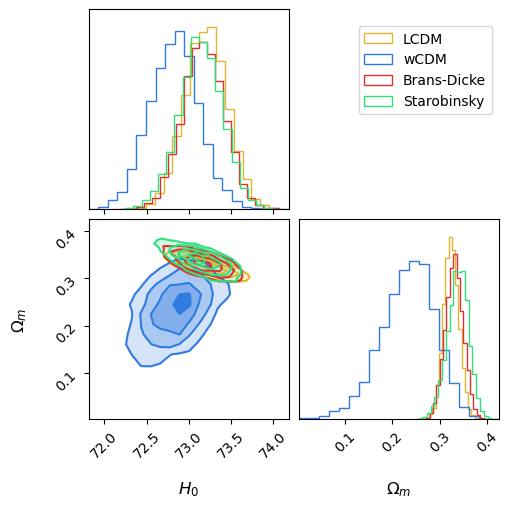

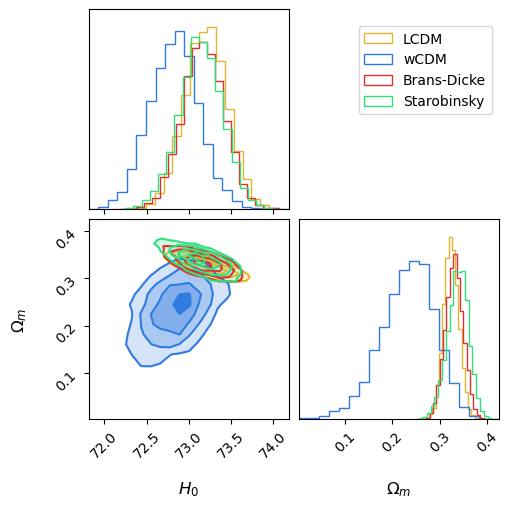

In [18]:
chains = [samples_lcdm, samples_wcdm, samples_bd, samples_st]
labels = [labels_lcdm, labels_wcdm, labels_bd, labels_st]
names = ["LCDM", "wCDM", "Brans-Dicke", "Starobinsky"]

compare_models_corner(chains, labels, names)

### B. Theoretical Curve Comparison
We plot the best-fit predictions for each model against the actual observational data.

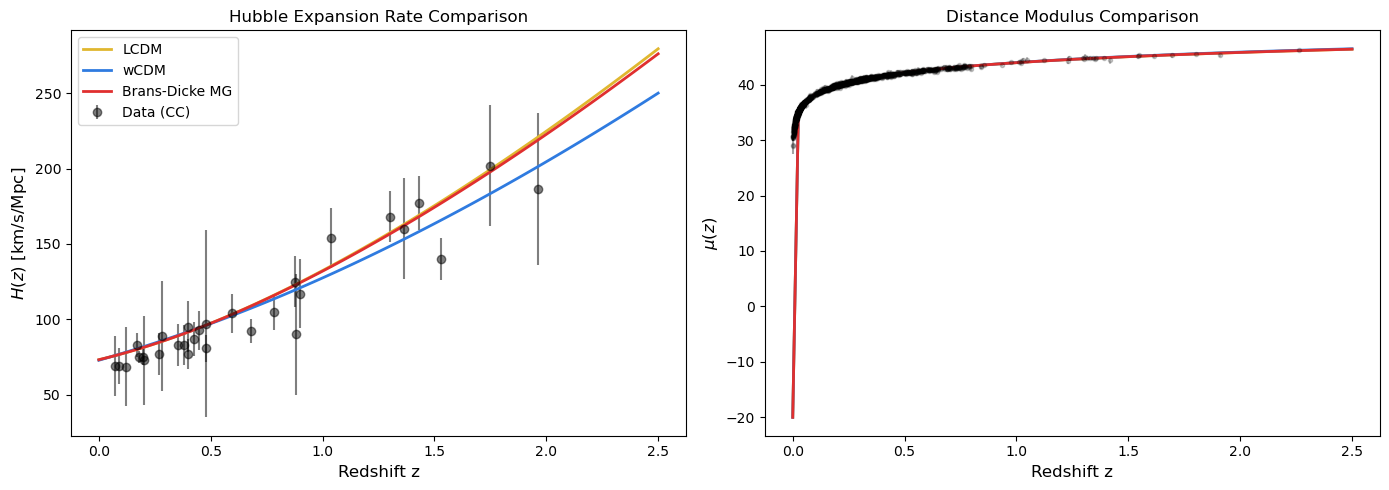

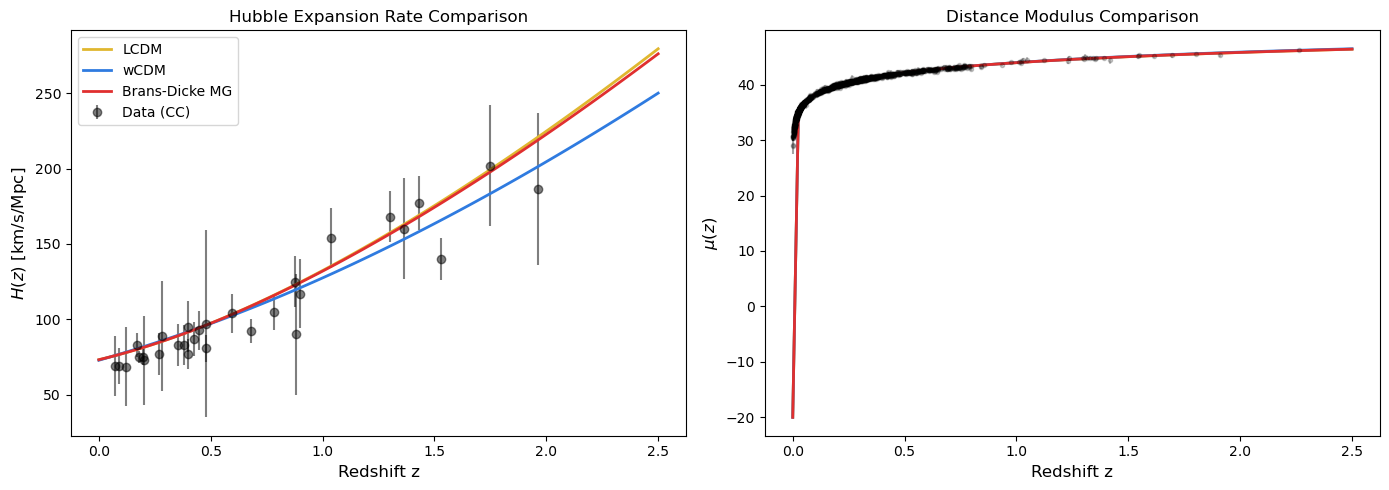

In [9]:
# Get best-fit parameters (medians)
bf_lcdm = [summary_lcdm[k][0] for k in labels_lcdm]
bf_wcdm = [summary_wcdm[k][0] for k in labels_wcdm]
bf_bd = [summary_bd[k][0] for k in labels_bd]

# Load data for plotting
data_CC = load_CC(cc_path)
data_SN = load_PPSH0ES(sn_path)

# Plot comparison
models = [LCDMModel(), wCDMModel(), BransDickeModel()]
params = [bf_lcdm, bf_wcdm, bf_bd]

plot_theory_comparison(models, params, data_CC=data_CC, data_SN=data_SN)